# Exploratory Data Analysis — Control Station OCE Data

## Objective

This notebook explores the 3-minute PID loop dataset for one paper machine.

The purpose of the EDA is to:

1. Validate the structure and quality of the dataset.
2. Understand the behavior and distribution of OCE and related control metrics.
3. Identify differences in performance across PID loops.
4. Detect unusual time periods, loops, or operating patterns.
5. Identify potential drivers of poor control performance.
6. Establish a reliable analytical foundation for later benchmarking and economic-loss analysis.

> This notebook is exploratory. Patterns identified here should not automatically be interpreted as causal relationships.

In [17]:
# Define the correct column names provided by Control Station
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns = [
    "LoopId",
    "resulttime",
    "OverallUptime",
    "StictionValue",
    "OverallHealth",
    "OverallOCE",
    "PercentageTimeInNormalMode",
    "AbsErrGoodFrac",
    "AAE",
    "NormalizedVariation",
    "PV_Average",
    "PVVariance",
    "COTravel",
    "ReversalsPerHour",
    "PercentTimeSaturated"
]

df = pd.read_csv(
    "../data/raw/3-minute data Jul.csv",
    header=None,
    names=columns
)

df.head()

,LoopId,resulttime,OverallUptime,StictionValue,OverallHealth,OverallOCE,PercentageTimeInNormalMode,AbsErrGoodFrac,AAE,NormalizedVariation,PV_Average,PVVariance,COTravel,ReversalsPerHour,PercentTimeSaturated
0,5,2025-07-01 00:00:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,63.214645,4.215731,3459.438232,3004.931641,0.389972,120.0,0.0
1,5,2025-07-01 00:03:00.0000000 +00:00,100.0,0.0,58.333333,41.111111,1.0,0.411111,52.528877,3.696444,3459.736816,3519.830811,0.407352,100.0,0.0
2,5,2025-07-01 00:06:00.0000000 +00:00,100.0,0.0,63.664583,36.666668,1.0,0.366667,40.776787,2.744100,3439.315186,1320.311401,0.355343,80.0,0.0
3,5,2025-07-01 00:09:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,54.010696,3.581736,3459.701416,1991.939819,0.460078,180.0,0.0
4,5,2025-07-01 00:12:00.0000000 +00:00,100.0,0.0,58.333333,36.666668,1.0,0.366667,56.769093,3.680142,3471.993652,2706.926270,0.364381,120.0,0.0


In [ ]:
#inital data inspection
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 10 rows:")
display(df.head(10))

Dataset shape: (1201478, 15)

Columns:
['LoopId', 'resulttime', 'OverallUptime', 'StictionValue', 'OverallHealth', 'OverallOCE', 'PercentageTimeInNormalMode', 'AbsErrGoodFrac', 'AAE', 'NormalizedVariation', 'PV_Average', 'PVVariance', 'COTravel', 'ReversalsPerHour', 'PercentTimeSaturated']

Data types:
LoopId                          int64
resulttime                        str
OverallUptime                 float64
StictionValue                 float64
OverallHealth                 float64
OverallOCE                    float64
PercentageTimeInNormalMode    float64
AbsErrGoodFrac                float64
AAE                           float64
NormalizedVariation           float64
PV_Average                    float64
PVVariance                    float64
COTravel                      float64
ReversalsPerHour              float64
PercentTimeSaturated          float64
dtype: object

First 10 rows:


,LoopId,resulttime,OverallUptime,StictionValue,OverallHealth,OverallOCE,PercentageTimeInNormalMode,AbsErrGoodFrac,AAE,NormalizedVariation,PV_Average,PVVariance,COTravel,ReversalsPerHour,PercentTimeSaturated
0,5,2025-07-01 00:00:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,63.214645,4.215731,3459.438232,3004.931641,0.389972,120.0,0.0
1,5,2025-07-01 00:03:00.0000000 +00:00,100.0,0.0,58.333333,41.111111,1.0,0.411111,52.528877,3.696444,3459.736816,3519.830811,0.407352,100.0,0.0
2,5,2025-07-01 00:06:00.0000000 +00:00,100.0,0.0,63.664583,36.666668,1.0,0.366667,40.776787,2.744100,3439.315186,1320.311401,0.355343,80.0,0.0
3,5,2025-07-01 00:09:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,54.010696,3.581736,3459.701416,1991.939819,0.460078,180.0,0.0
4,5,2025-07-01 00:12:00.0000000 +00:00,100.0,0.0,58.333333,36.666668,1.0,0.366667,56.769093,3.680142,3471.993652,2706.926270,0.364381,120.0,0.0
5,5,2025-07-01 00:15:00.0000000 +00:00,100.0,0.0,58.333333,28.888889,1.0,0.288889,70.660530,4.868598,3497.090332,2741.852051,0.629808,180.0,0.0
6,5,2025-07-01 00:18:00.0000000 +00:00,100.0,0.0,58.333333,24.444445,1.0,0.244444,65.464050,3.959182,3521.630371,2824.932861,0.276270,80.0,0.0
7,5,2025-07-01 00:21:00.0000000 +00:00,100.0,0.0,83.511577,86.666664,1.0,0.866667,26.801765,1.791444,3372.719971,859.642273,0.131963,60.0,0.0
8,5,2025-07-01 00:24:00.0000000 +00:00,100.0,0.0,58.333333,33.333336,1.0,0.333333,68.247078,4.711651,3355.276611,1688.857178,0.505975,160.0,0.0
9,5,2025-07-01 00:27:00.0000000 +00:00,100.0,0.0,61.157808,85.555557,1.0,0.855556,34.887478,2.864425,3435.649170,3434.660889,0.226443,240.0,0.0


## 2. Data Structure and Coverage

Before analyzing control performance, we first establish the scope and temporal coverage of the dataset.

This section answers four basic questions:

- How many observations are available?
- How many unique PID loops are represented?
- What time period does the dataset cover?
- Is the expected 3-minute sampling interval consistent across the data?

In [30]:
#convert timestamp 
df["resulttime"] = pd.to_datetime(df["resulttime"], errors="coerce")

#basic dataset coverage
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Unique loops: {df['LoopId'].nunique():,}")
print(f"Start time: {df['resulttime'].min()}")
print(f"End time: {df['resulttime'].max()}")

Number of rows: 1,201,478
Number of columns: 15
Unique loops: 94
Start time: 2025-07-01 00:00:00+00:00
End time: 2025-07-31 23:57:00+00:00


### 2.1 Observations by Loop

Next, we examine how many observations are available for each PID loop.

Large differences in record counts may indicate incomplete coverage, differences in loop availability, or other data-quality issues that should be investigated before comparing loop performance.

In [ ]:
#foundation statiscal 
loop_counts = (
    df.groupby("LoopId")
      .size()
      .sort_values(ascending=False)
)

display(loop_counts.describe())

display(loop_counts.head(10))
display(loop_counts.tail(10))

count       94.000000
mean     12781.680851
std       3352.384278
min          3.000000
25%      13607.000000
50%      13607.000000
75%      14067.000000
max      14880.000000
dtype: float64

LoopId
5      14880
439    14857
312    14769
458    14235
438    14235
466    14235
461    14235
462    14235
460    14235
463    14235
dtype: int64

LoopId
293    12421
297    11041
425     7855
421     7853
440     1852
441     1670
295       11
294       11
420        3
422        3
dtype: int64

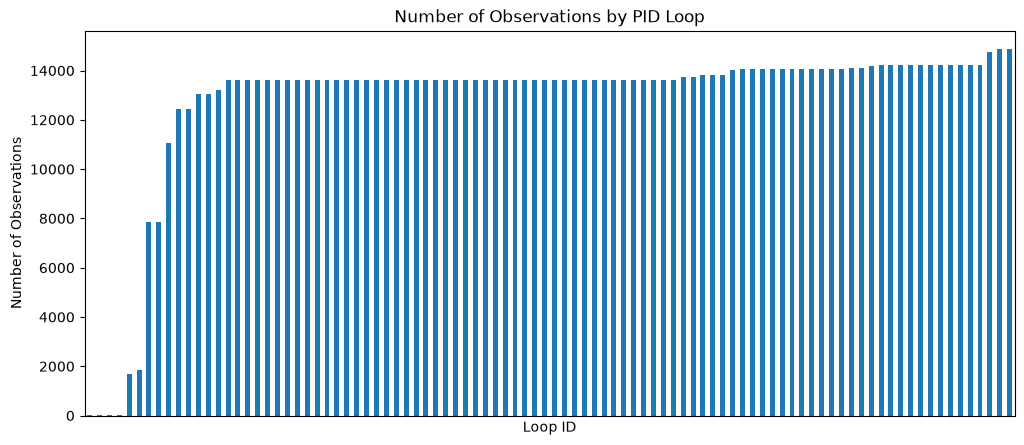

In [ ]:
#visualize number of observation by PID loop
plt.figure(figsize=(12, 5))

loop_counts.sort_values().plot(kind="bar")

plt.title("Number of Observations by PID Loop")
plt.xlabel("Loop ID")
plt.ylabel("Number of Observations")
plt.xticks([])
plt.show()

In [26]:
#sort data before time analysis 
df = df.sort_values(
    ["LoopId", "resulttime"]
).reset_index(drop=True)

In [33]:
df["time_diff"] = (
    df.groupby("LoopId")["resulttime"]
      .diff()
)

df["time_diff"].value_counts().head(10)

time_diff
0 days 00:03:00    1199598
0 days 00:30:00        242
0 days 00:45:00        138
0 days 01:00:00        112
0 days 00:51:00        104
0 days 00:42:00         97
0 days 00:09:00         64
0 days 01:51:00         54
0 days 01:12:00         53
0 days 07:00:00         51
Name: count, dtype: int64

In [34]:
# Remove NaT values from the first observation of each loop
valid_diff = df["time_diff"].dropna()

# Calculate the percentage of intervals that are exactly 3 minutes
three_min_pct = (
    valid_diff.eq(pd.Timedelta(minutes=3)).mean() * 100
)

print(f"Intervals exactly 3 minutes apart: {three_min_pct:.2f}%")

Intervals exactly 3 minutes apart: 99.85%


In [39]:
# Calculate the percentage of intervals greater than 3 minutes
gap_pct = (
    (valid_diff > pd.Timedelta(minutes=3)).mean() * 100
)

print(f"Intervals greater than 3 minutes: {gap_pct:.2f}%")

Intervals greater than 3 minutes: 0.15%


In [40]:
# Identify observations where the previous record is more than 3 minutes away
gaps = df[
    df["time_diff"] > pd.Timedelta(minutes=3)
]

# Count the total number of detected time gaps
print(f"Number of intervals > 3 minutes: {len(gaps):,}")

Number of intervals > 3 minutes: 1,786


In [41]:
# Find the 20 largest time gaps in the dataset
largest_gaps = (
    gaps[
        ["LoopId", "resulttime", "time_diff"]
    ]
    .sort_values("time_diff", ascending=False)
    .head(20)
)

# Display the largest gaps
display(largest_gaps)

,LoopId,resulttime,time_diff
670182,441,2025-07-27 08:12:00+00:00,8 days 09:12:00
520016,421,2025-07-23 09:06:00+00:00,4 days 12:06:00
527872,425,2025-07-23 09:06:00+00:00,4 days 12:06:00
670168,441,2025-07-18 22:21:00+00:00,3 days 07:21:00
669105,440,2025-07-21 14:12:00+00:00,2 days 09:12:00
528748,425,2025-07-27 08:36:00+00:00,1 days 14:45:00
520892,421,2025-07-27 08:36:00+00:00,1 days 14:45:00
517600,421,2025-07-12 11:06:00+00:00,1 days 11:36:00
525456,425,2025-07-12 11:06:00+00:00,1 days 11:36:00
515959,421,2025-07-06 23:21:00+00:00,1 days 08:30:00


In [42]:
# Count the number of time gaps for each PID loop
gap_by_loop = (
    gaps.groupby("LoopId")
        .size()
        .sort_values(ascending=False)
        .rename("gap_count")
)

# Show the 15 loops with the most time gaps
display(gap_by_loop.head(15))

LoopId
440    246
686     28
406     25
419     25
650     25
402     24
399     24
396     24
400     24
297     24
6       24
407     24
404     24
405     24
401     24
Name: gap_count, dtype: int64